Upload the Dataset


In [3]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_returns_synthetic_data.csv to ecommerce_returns_synthetic_data.csv


Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

Load Dataset

In [5]:
df = pd.read_csv("ecommerce_returns_synthetic_data.csv")

df.head()


,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


Understand the Dataset

1. Shape

In [6]:
df.shape

(10000, 17)

2. Column Names

In [7]:
df.columns

Index(['Order_ID', 'Product_ID', 'User_ID', 'Order_Date', 'Return_Date',
       'Product_Category', 'Product_Price', 'Order_Quantity', 'Return_Reason',
       'Return_Status', 'Days_to_Return', 'User_Age', 'User_Gender',
       'User_Location', 'Payment_Method', 'Shipping_Method',
       'Discount_Applied'],
      dtype='object')

3. Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       5052 non-null   object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     5052 non-null   object 
 9   Return_Status     10000 non-null  object 
 10  Days_to_Return    5052 non-null   float64
 11  User_Age          10000 non-null  int64  
 12  User_Gender       10000 non-null  object 
 13  User_Location     10000 non-null  object 
 14  Payment_Method    10000 non-null  object 
 15  Shipping_Method   10000 non-null  object 
 16  Discount_Applied  10000 non-null  float64

4. First Few Records

In [9]:
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


Check missing values

In [10]:
df.isnull().sum()

,0
Order_ID,0
Product_ID,0
User_ID,0
Order_Date,0
Return_Date,4948
Product_Category,0
Product_Price,0
Order_Quantity,0
Return_Reason,4948
Return_Status,0


In [11]:
df['Return_Status'].value_counts()

,count
Return_Status,
Returned,5052
Not Returned,4948


Return_status

In [12]:
df[df['Return_Status'] == 'Not Returned'][['Return_Date', 'Return_Reason', 'Days_to_Return']].head()

,Return_Date,Return_Reason,Days_to_Return
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
10,NaN,NaN,NaN
11,NaN,NaN,NaN


Handling missing values

1. Return_Date

In [13]:
df['Return_Date'] = df['Return_Date'].fillna('Not Returned')

2. Return_Reason

In [14]:
df['Return_Reason'] = df['Return_Reason'].fillna('Not Returned')

3. Days_to_Return

In [15]:
df['Days_to_Return'] = df['Days_to_Return'].fillna(0)

Check Duplicate Records

In [16]:
df.duplicated().sum()

np.int64(0)

Total Orders

In [18]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 10000


Total Returned Products

In [19]:
returned_products = len(
    df[df["Return_Status"]=="Returned"]
)

print("Returned Products:", returned_products)

Returned Products: 5052


Return Percentage

In [20]:
return_percentage = (
    returned_products / total_orders
)*100

print(return_percentage)

50.519999999999996


Descriptive Statistics

Numerical Summary

In [21]:
df.describe()

,Product_Price,Order_Quantity,Days_to_Return,User_Age,Discount_Applied
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,252.369307,3.006100,0.734400,44.195000,24.992162
std,142.883865,1.406791,211.789658,15.311983,14.363396
min,5.010000,1.000000,-719.000000,18.000000,0.000000
25%,128.650000,2.000000,-2.250000,31.000000,12.752500
50%,250.445000,3.000000,0.000000,44.000000,24.840000
75%,377.837500,4.000000,6.000000,57.000000,37.605000
max,499.890000,5.000000,726.000000,70.000000,50.000000


Average Product Price

In [22]:
df["Product_Price"].mean()

np.float64(252.36930700000002)

Median Price

In [23]:
df["Product_Price"].median()

250.445

Standard Deviation

In [24]:
df["Product_Price"].std()

142.88386490109585

Average Discount

In [25]:
df["Discount_Applied"].mean()

np.float64(24.992162)

Average Days to Return

In [26]:
df["Days_to_Return"].mean()

np.float64(0.7344)

Distribution Analysis

Product Price Histogram


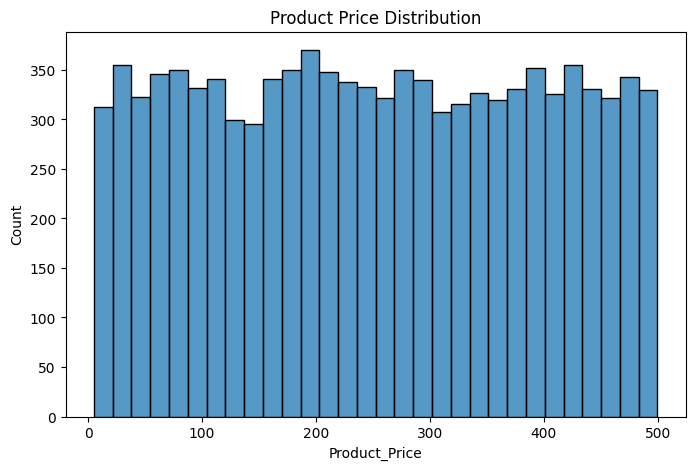

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Product_Price"],
    bins=30
)

plt.title("Product Price Distribution")
plt.show()

Discount Histogram

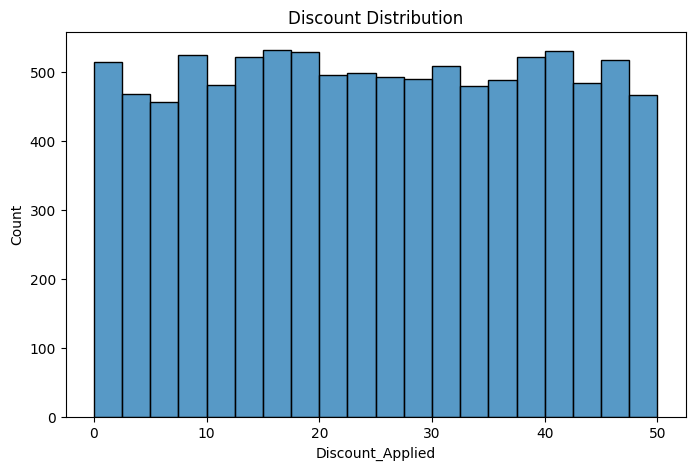

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Discount_Applied"],
    bins=20
)

plt.title("Discount Distribution")
plt.show()

Return Pattern Investigation

Category vs Return Rate


In [35]:
category_returns = pd.crosstab(
    df["Product_Category"],
    df["Return_Status"]
)

category_returns

Return_Status,Not Returned,Returned
Product_Category,,
Books,1007,1034
Clothing,951,1049
Electronics,974,1011
Home,1035,995
Toys,981,963


Category Return Visualization

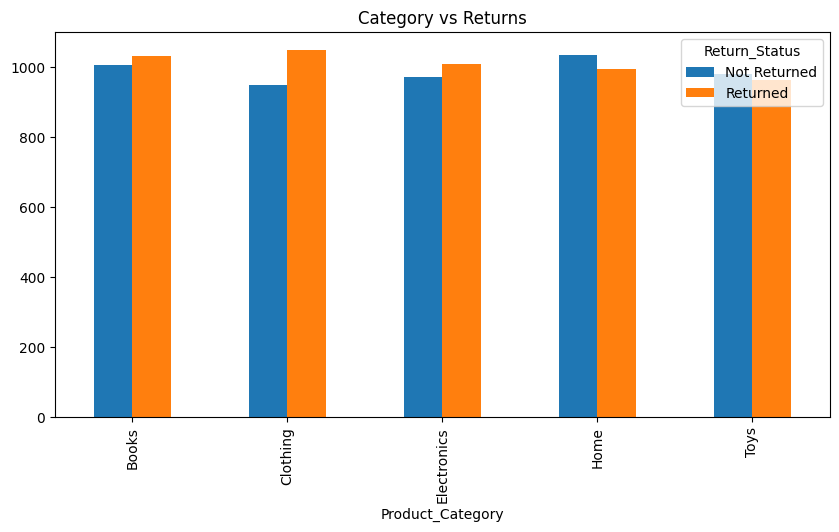

In [36]:
category_returns.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Category vs Returns")
plt.show()

Price vs Return

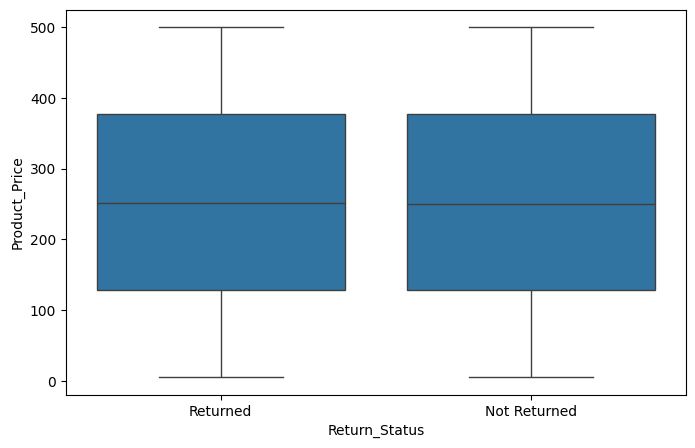

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Return_Status",
    y="Product_Price",
    data=df
)

plt.show()

Discount vs Return

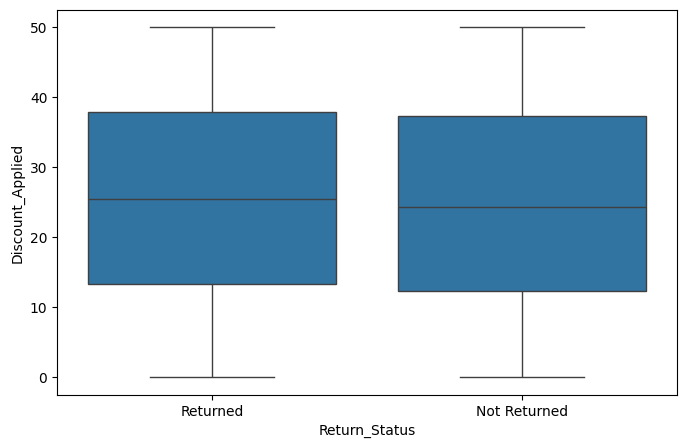

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Return_Status",
    y="Discount_Applied",
    data=df
)

plt.show()

Days to Return

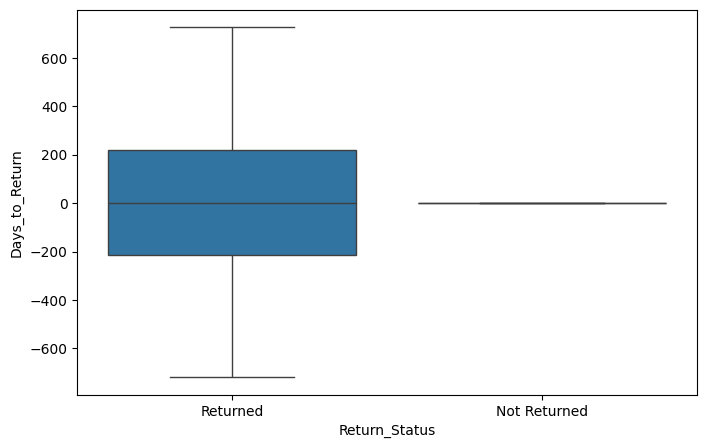

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Return_Status",
    y="Days_to_Return",
    data=df
)

plt.show()

Return Reason Analysis

In [37]:
df["Return_Reason"].value_counts()

,count
Return_Reason,
Not Returned,4948
Defective,1327
Wrong item,1258
Changed mind,1255
Not as described,1212


Visualization

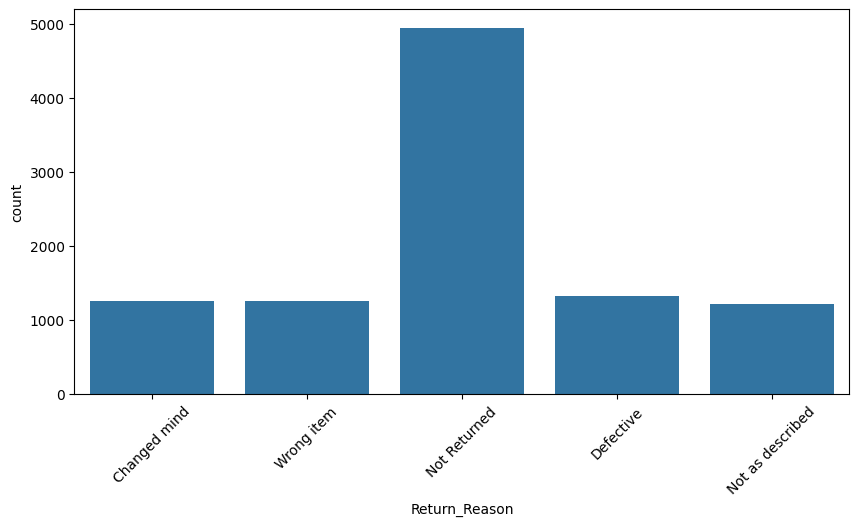

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Return_Reason",
    data=df
)

plt.xticks(rotation=45)

plt.show()

Shipping Method Analysis

In [39]:
pd.crosstab(
    df["Shipping_Method"],
    df["Return_Status"]
)

Return_Status,Not Returned,Returned
Shipping_Method,,
Express,1655,1651
Next-Day,1660,1734
Standard,1633,1667


Visualization

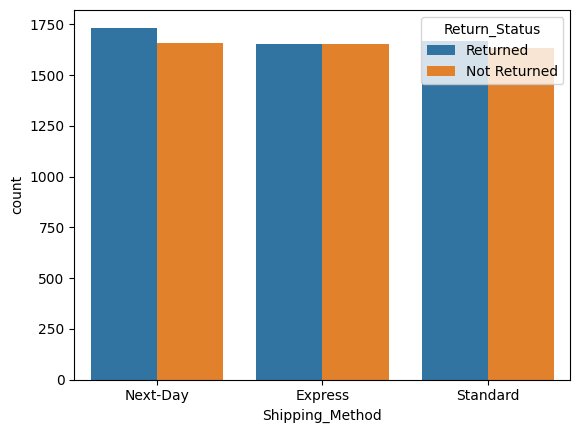

In [40]:
sns.countplot(
    x="Shipping_Method",
    hue="Return_Status",
    data=df
)

plt.show()

Correlation Analysis

In [41]:
numeric_df = df.select_dtypes(
    include=np.number
)

Heatmap

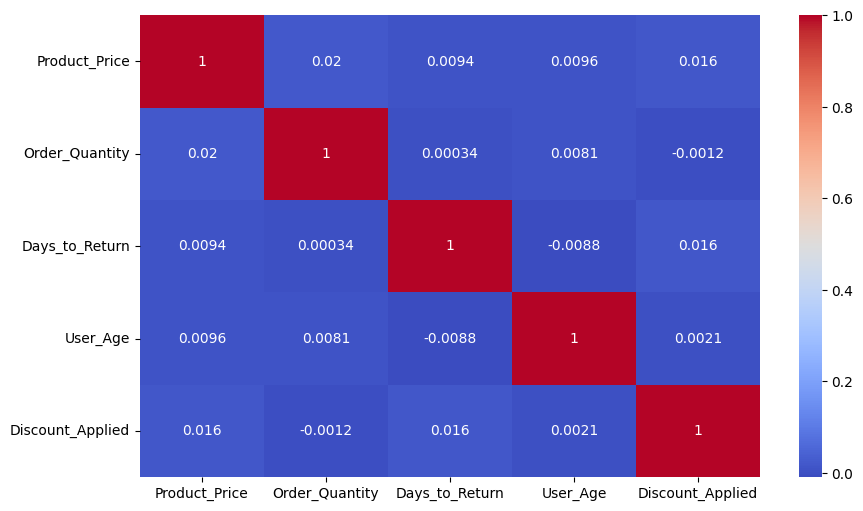

In [42]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Outlier Analysis

Product Price Outliers

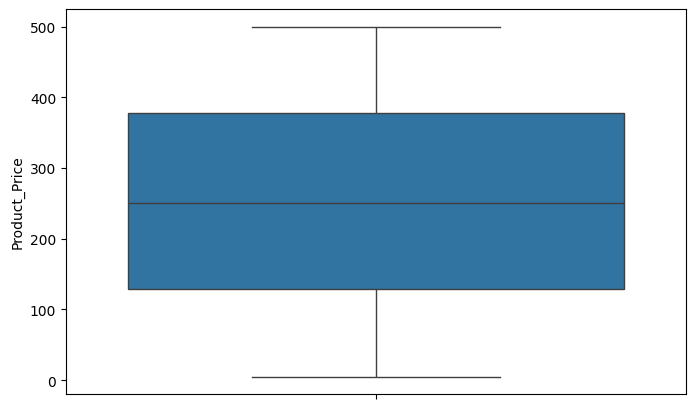

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Product_Price"]
)

plt.show()

IQR Method

In [44]:
Q1 = df["Product_Price"].quantile(0.25)

Q3 = df["Product_Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df[
    (df["Product_Price"] < lower)
    |
    (df["Product_Price"] > upper)
]

outliers.shape

(0, 17)

Hypothesis Testing

In [45]:
returned = df[
    df["Return_Status"]=="Returned"
]["Product_Price"]

not_returned = df[
    df["Return_Status"]=="Not Returned"
]["Product_Price"]

Run T-Test

In [46]:
t_stat, p_value = ttest_ind(
    returned,
    not_returned
)

print(p_value)

0.9368727535602055


Interpretation

In [47]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


Customer Segmentation

High Return Customers



In [48]:
customer_returns = (
    df.groupby("User_ID")
    ["Return_Status"]
    .count()
)

customer_returns.sort_values(
    ascending=False
).head(10)

,Return_Status
User_ID,
USER00009983,1
USER00009982,1
USER00009981,1
USER00009980,1
USER00009979,1
USER00009978,1
USER00009977,1
USER00009976,1
USER00009975,1


Premium Customers

In [49]:
premium_customers = df[
    df["Product_Price"] > 5000
]

premium_customers.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied


High Discount Customers

In [50]:
discount_customers = df[
    df["Discount_Applied"] > 40
]

discount_customers.head()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
5,ORD00000005,PROD00000005,USER00000005,2024-02-14,2024-09-22,Electronics,252.12,1,Defective,Returned,221.0,46,Female,City47,Debit Card,Next-Day,47.61
9,ORD00000009,PROD00000009,USER00000009,2023-03-10,2024-01-21,Clothing,294.94,3,Not as described,Returned,317.0,44,Male,City82,Credit Card,Standard,45.21
19,ORD00000019,PROD00000019,USER00000019,2024-07-06,2024-05-01,Electronics,227.94,5,Changed mind,Returned,-66.0,50,Female,City64,Debit Card,Express,43.86
